In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
output_dir=Path("results")
dfs = [pd.read_csv(f) for f in output_dir.rglob("data.csv")]
df = pd.concat(dfs, ignore_index=True)
df.head(100)

,seed,DX,D_diff,time,error
0,10,0.15,0.0,0.00,0.413282
1,10,0.15,0.0,0.02,0.377899
2,10,0.15,0.0,0.04,0.362270
3,10,0.15,0.0,0.06,0.350465
4,10,0.15,0.0,0.08,0.337236
...,...,...,...,...,...
95,10,0.15,10.0,0.38,0.314401
96,10,0.15,10.0,0.40,0.312213
97,10,0.15,10.0,0.42,0.307818
98,10,0.15,10.0,0.44,0.307483


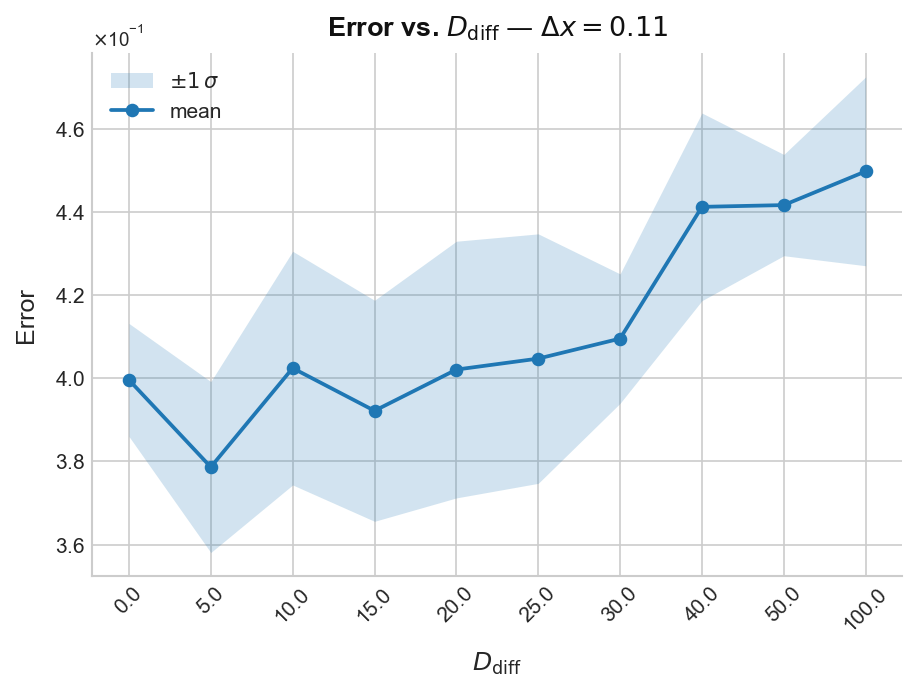

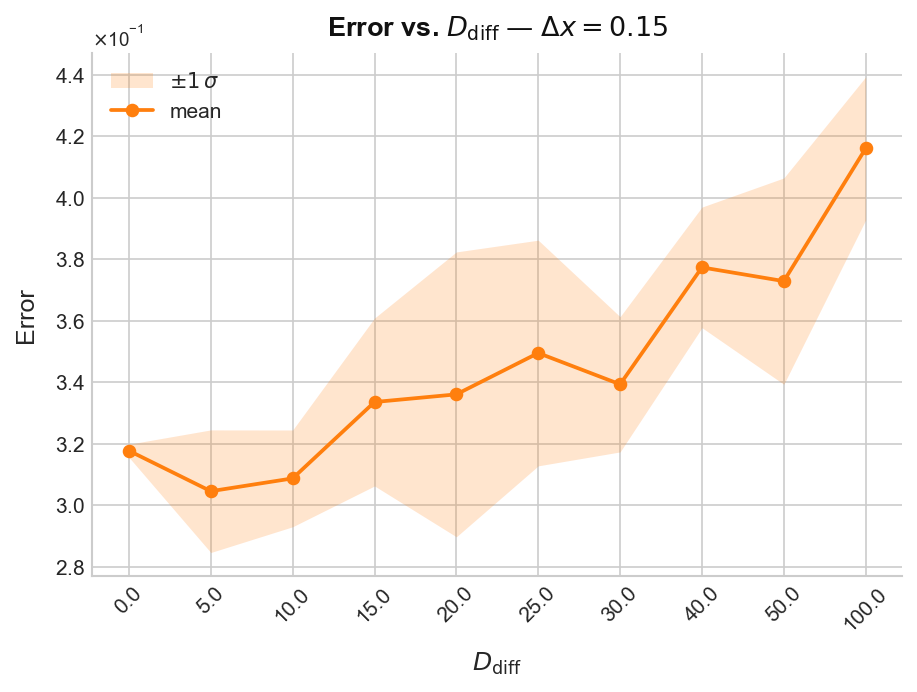

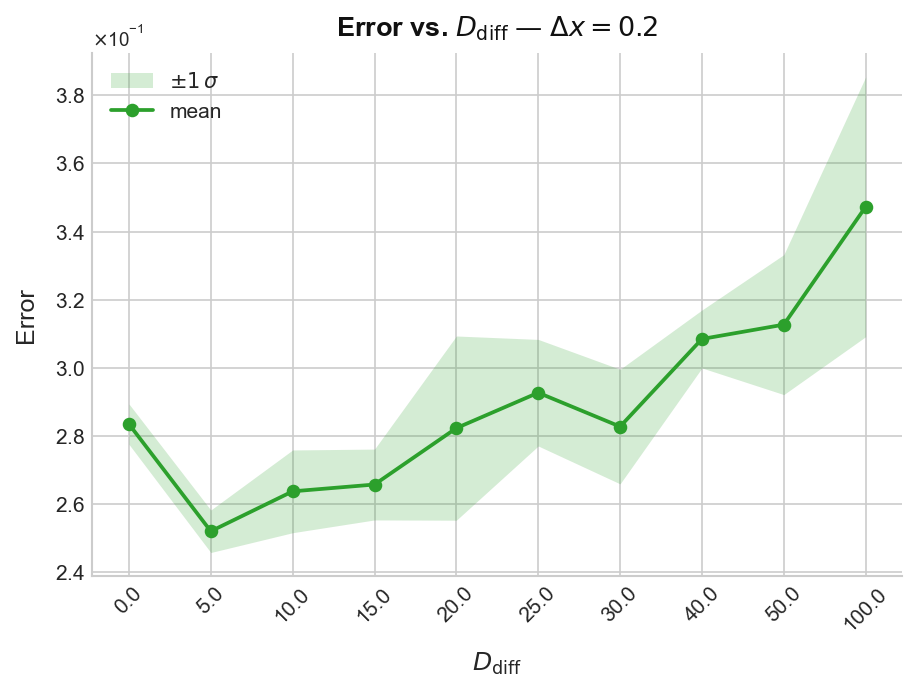

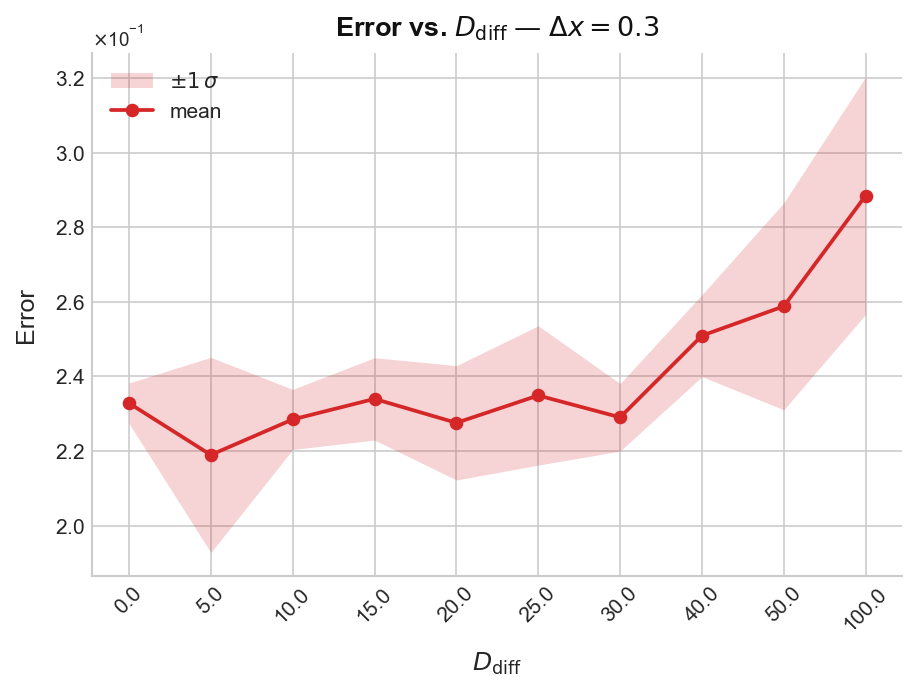

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Data preparation ──────────────────────────────────────────────────────────
df_last = df[df["time"] == 0.74]

df_stats = (
    df_last.groupby(["D_diff", "DX"])["error"]
    .agg(mean="mean", std="std")
    .reset_index()
)

dx_values = sorted(df_stats["DX"].unique())
CMAP      = plt.get_cmap("tab10")

plt.style.use("seaborn-v0_8-whitegrid")

# ── One independent figure per DX ────────────────────────────────────────────
for i, dx in enumerate(dx_values):
    sub = df_stats[df_stats["DX"] == dx].sort_values("D_diff")

    # categorical x-axis
    x_labels = sub["D_diff"].astype(str).values
    x_pos    = range(len(x_labels))

    mean  = sub["mean"].values
    std   = sub["std"].fillna(0).values
    color = CMAP(i)

    fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)

    # ±1 σ shaded band
    ax.fill_between(
        x_pos, mean - std, mean + std,
        alpha=0.20, color=color, linewidth=0,
        label=r"$\pm 1\,\sigma$",
    )

    # mean line + markers
    ax.plot(
        x_pos, mean,
        marker="o", markersize=5.5, linewidth=1.8,
        color=color, label="mean",
    )

    # ── Formatting ────────────────────────────────────────────────────────────
    ax.set_title(
        rf"Error vs. $D_{{\mathrm{{diff}}}}$ — $\Delta x = {dx}$",
        fontsize=13, fontweight="bold", pad=8,
    )
    ax.set_xlabel(r"$D_{\mathrm{diff}}$", fontsize=12)
    ax.set_ylabel("Error", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(x_labels, rotation=45)

    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.6)

    fig.savefig(f"error_dx_{dx}.png", dpi=150)

plt.show()

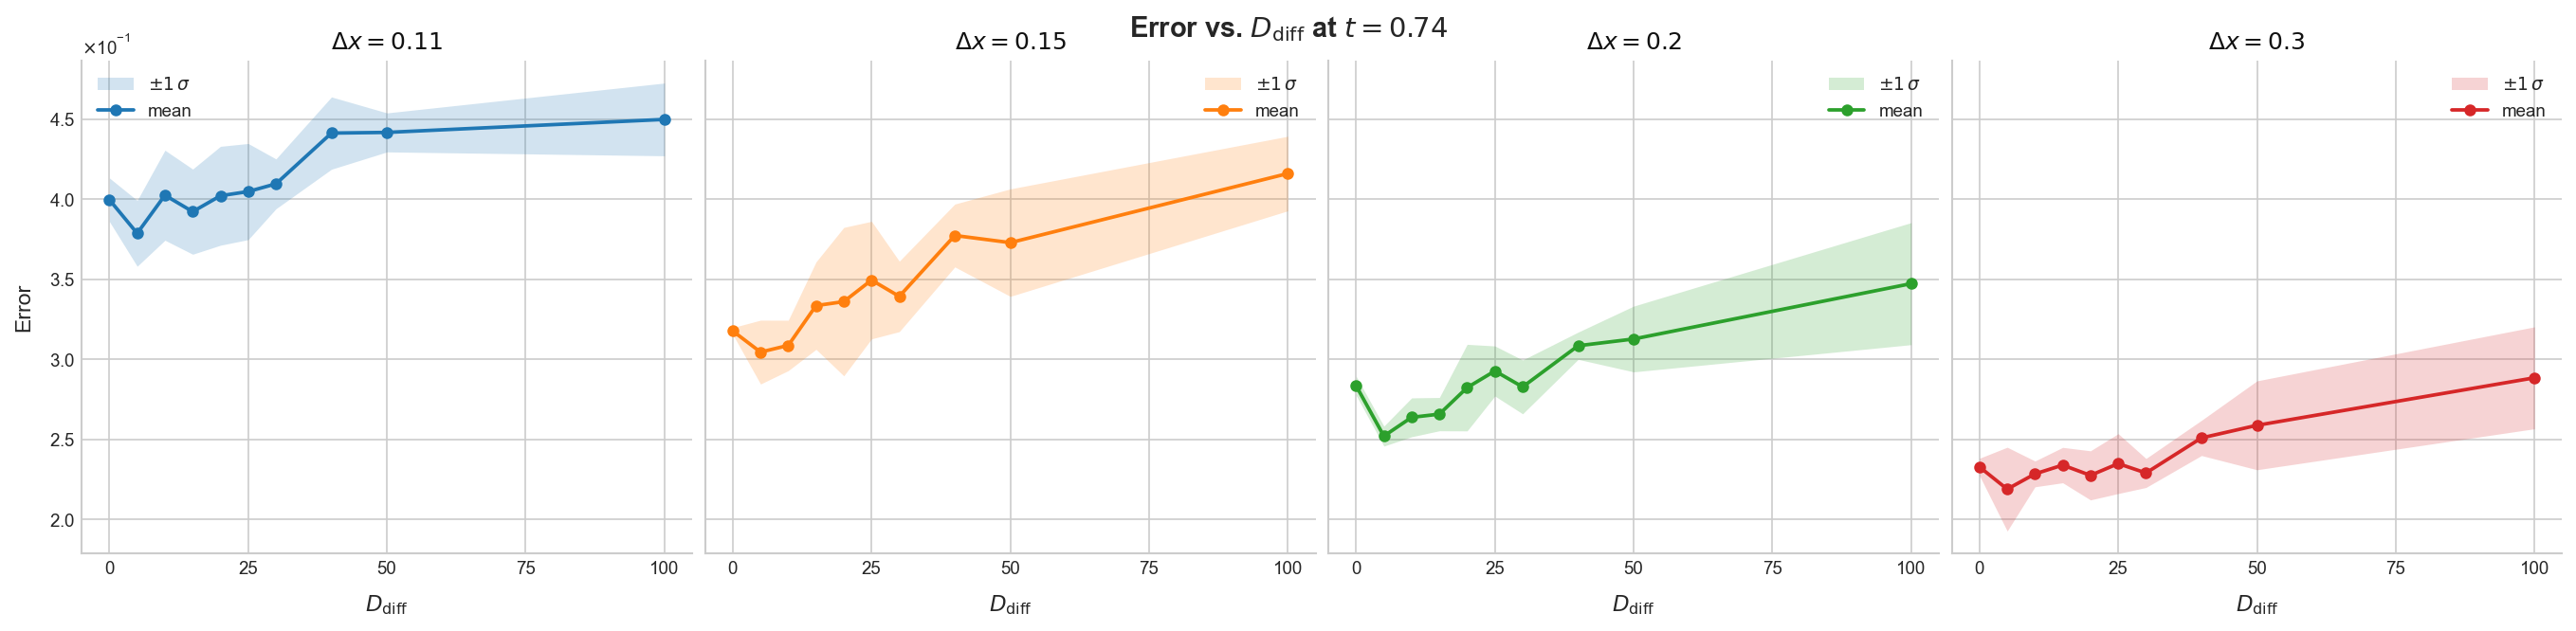

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Data preparation ──────────────────────────────────────────────────────────
df_last = df[df["time"] == 0.74]

df_stats = (
    df_last.groupby(["D_diff", "DX"])["error"]
    .agg(mean="mean", std="std")
    .reset_index()
)

dx_values = sorted(df_stats["DX"].unique())
n = len(dx_values)

# ── Scientific style ──────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

CMAP   = plt.get_cmap("tab10")
COLORS = [CMAP(i) for i in range(n)]

fig, axes = plt.subplots(
    1, n,
    figsize=(4.5 * n, 4.2),
    sharey=True,
    constrained_layout=True,
)

if n == 1:          # keep axes always iterable
    axes = [axes]

fig.suptitle(
    r"Error vs. $D_{\mathrm{diff}}$ at $t = 0.74$",
    fontsize=14, fontweight="bold", y=1.02,
)

for ax, dx, color in zip(axes, dx_values, COLORS):
    sub = df_stats[df_stats["DX"] == dx].sort_values("D_diff")

    x    = sub["D_diff"].values
    mean = sub["mean"].values
    std  = sub["std"].fillna(0).values

    # shaded ±1 σ band
    ax.fill_between(
        x, mean - std, mean + std,
        alpha=0.20, color=color, linewidth=0,
        label=r"$\pm 1\,\sigma$",
    )

    # mean line + markers
    ax.plot(
        x, mean,
        marker="o", markersize=5, linewidth=1.8,
        color=color, label="mean",
    )

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_title(rf"$\Delta x = {dx}$", fontsize=12, pad=6)
    ax.set_xlabel(r"$D_{\mathrm{diff}}$", fontsize=11)
    ax.tick_params(axis="both", labelsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.6)

# shared y-label on the leftmost panel only
axes[0].set_ylabel("Error", fontsize=11)

plt.show()

In [16]:
df["mean"] = df.groupby(["D_diff", "DX"])["error"].transform("mean")

In [17]:
df.head(12)

,seed,DX,D_diff,time,error,mean
0,10,0.15,0.0,0.00,0.413282,0.32688
1,10,0.15,0.0,0.02,0.377899,0.32688
2,10,0.15,0.0,0.04,0.362270,0.32688
3,10,0.15,0.0,0.06,0.350465,0.32688
4,10,0.15,0.0,0.08,0.337236,0.32688
5,10,0.15,0.0,0.10,0.337843,0.32688
6,10,0.15,0.0,0.12,0.335921,0.32688
7,10,0.15,0.0,0.14,0.328152,0.32688
8,10,0.15,0.0,0.16,0.315903,0.32688
9,10,0.15,0.0,0.18,0.319565,0.32688


In [18]:
df.to_csv("filename.csv", index=False)

In [19]:
df_last=df[df["time"]==0.74]
df_last.head(11)

,seed,DX,D_diff,time,error,mean
37,10,0.15,0.0,0.74,0.317191,0.326880
75,10,0.15,5.0,0.74,0.280943,0.330842
113,10,0.15,10.0,0.74,0.321837,0.338219
151,10,0.15,15.0,0.74,0.374730,0.354039
189,10,0.15,20.0,0.74,0.312775,0.358875
227,10,0.15,25.0,0.74,0.320971,0.368145
265,10,0.15,30.0,0.74,0.362220,0.377088
303,10,0.15,40.0,0.74,0.406662,0.380373
341,10,0.15,50.0,0.74,0.346171,0.377442
379,10,0.15,100.0,0.74,0.383480,0.411835


In [20]:
df_mean = df_last.groupby(["D_diff", "DX"])[["error"]].mean()

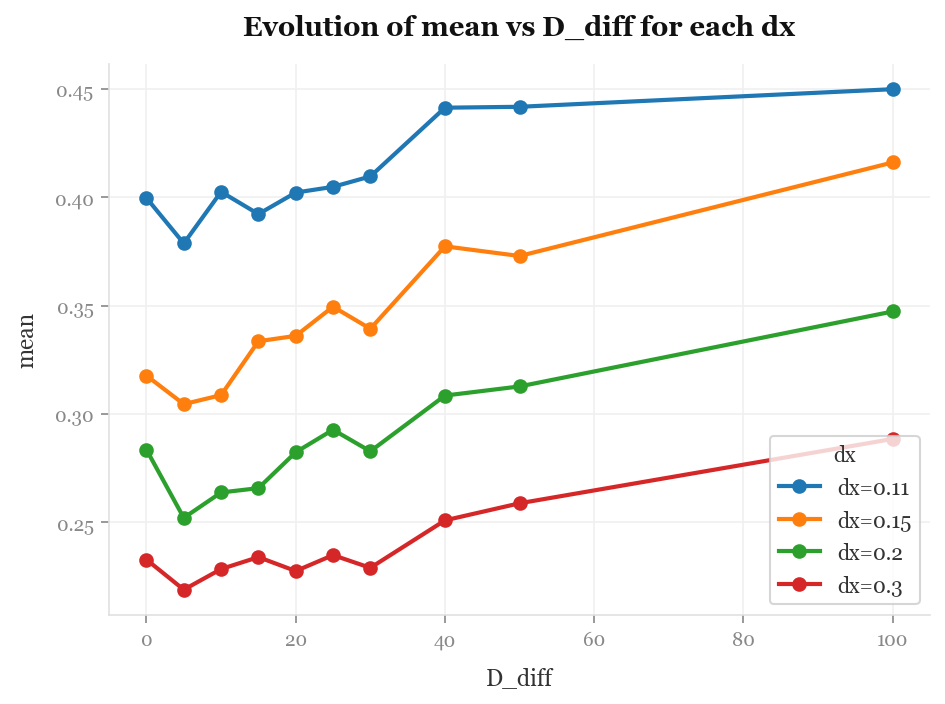

In [ ]:
import matplotlib.pyplot as plt
df_last=df[df["time"]==0.74]

df_mean = df_last.groupby(["D_diff", "DX"])[["error"]].mean()
for dx, group in df_mean.groupby('DX'):
    plt.plot(group.index.get_level_values('D_diff'), group['error'], marker='o', label=f'dx={dx}')

plt.xlabel('D_diff')
plt.ylabel('mean')
plt.title('Evolution of mean vs D_diff for each dx')
plt.legend(title='dx')
plt.grid(True)
plt.tight_layout()
plt.show()

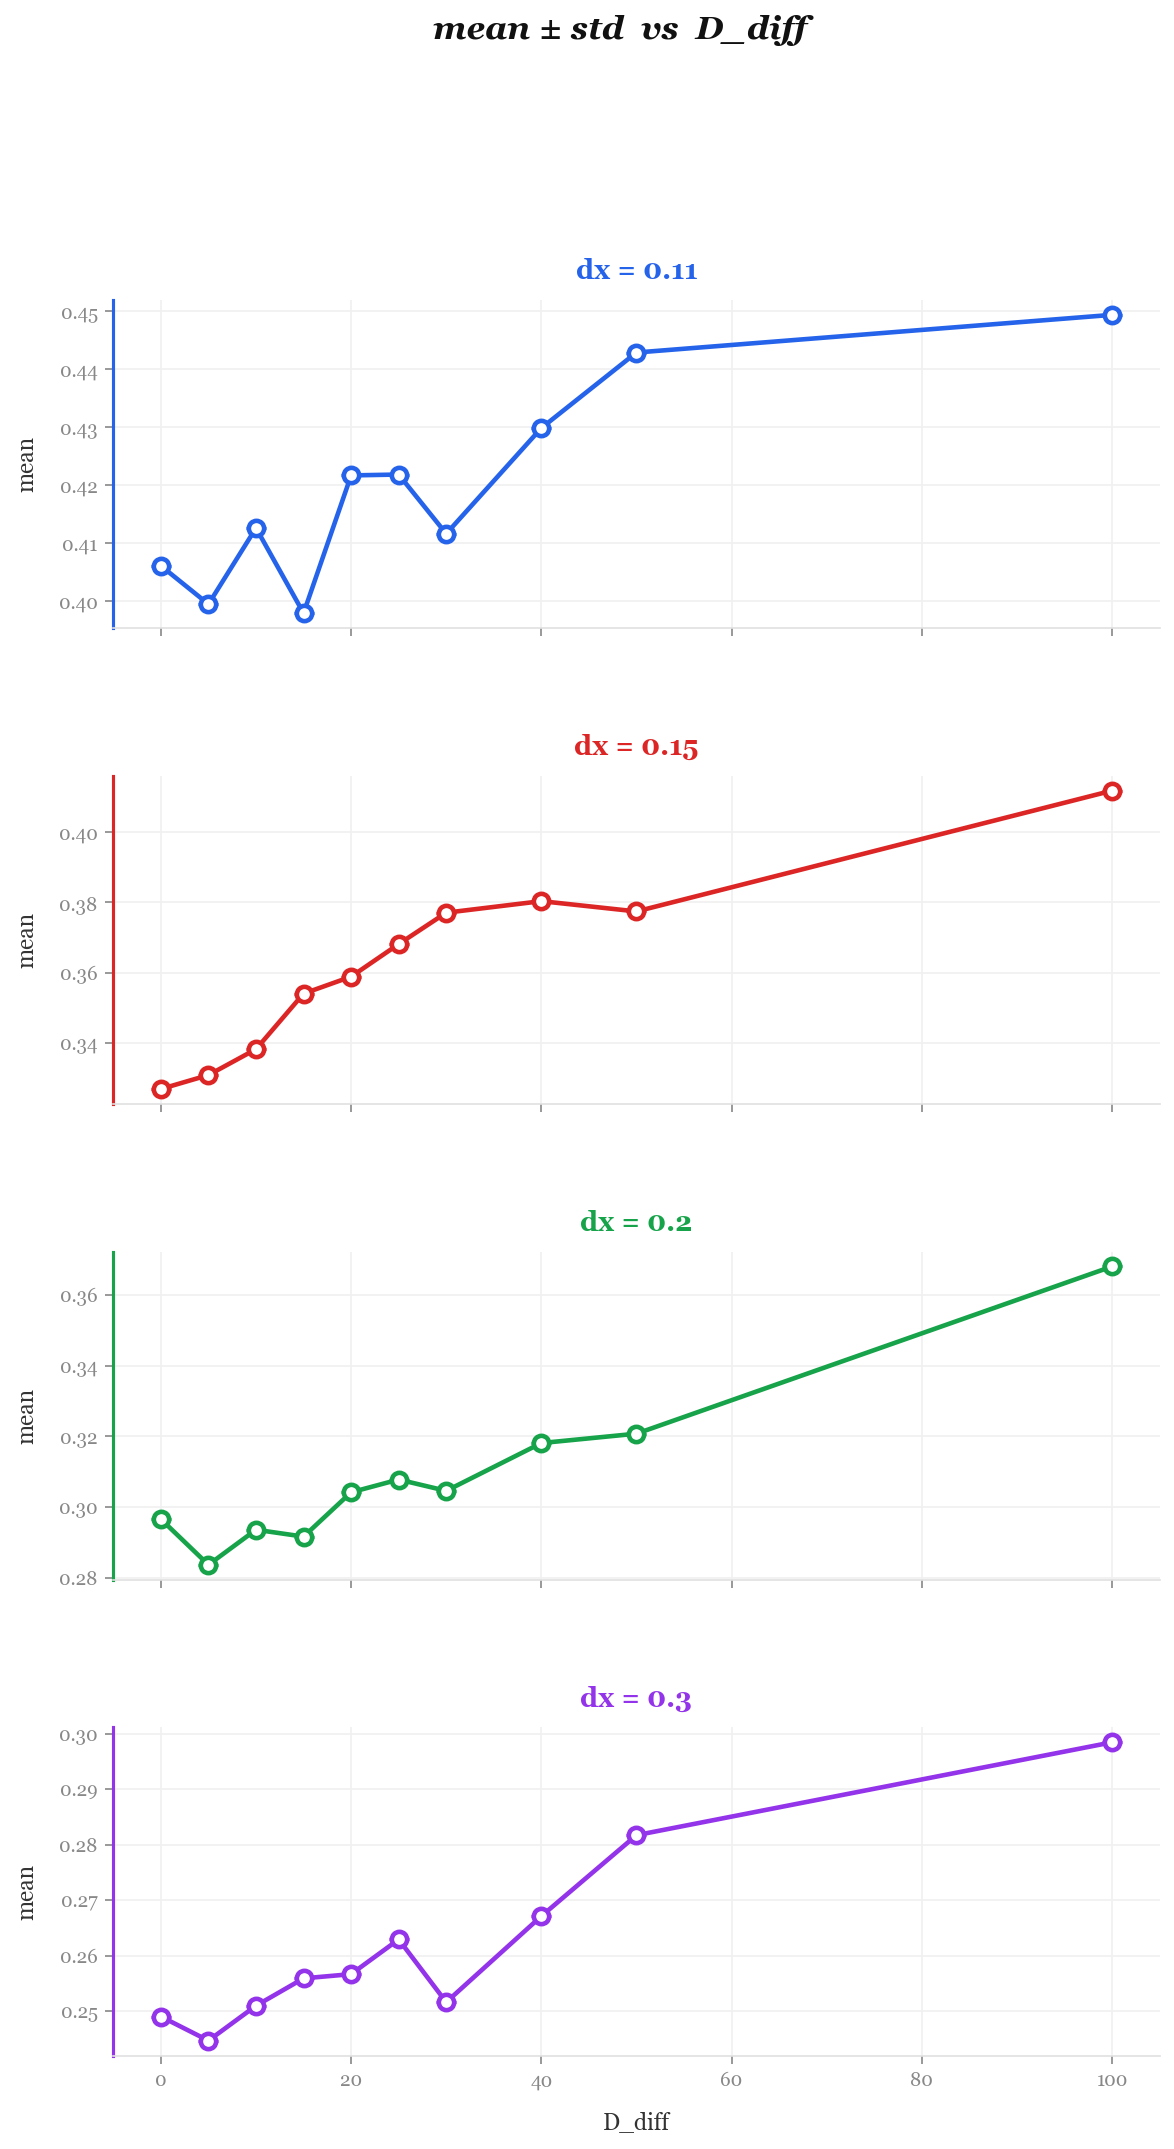

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#e0e0e0",
    "axes.labelcolor":   "#333333",
    "axes.titlecolor":   "#111111",
    "axes.titlesize":    13,
    "axes.titleweight":  "semibold",
    "axes.titlepad":     14,
    "axes.labelsize":    11,
    "axes.labelpad":     8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#f0f0f0",
    "grid.linewidth":    0.8,
    "xtick.color":       "#888888",
    "ytick.color":       "#888888",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "lines.linewidth":   2,
    "font.family":       "serif",
    "font.serif":        ["Georgia", "DejaVu Serif"],
    "text.color":        "#333333",
    "figure.dpi":        150,
})

# ── Palette ───────────────────────────────────────────────────────────────────
PALETTE = [
    "#2563eb",  # blue
    "#dc2626",  # red
    "#16a34a",  # green
    "#9333ea",  # purple
    "#ea580c",  # orange
    "#0891b2",  # teal
]

# ── Data ──────────────────────────────────────────────────────────────────────
df_stats = df_last.groupby(["D_diff", "DX"])["mean"].agg(["mean", "std"]).reset_index()
dx_list  = sorted(df_stats["DX"].unique())
n        = len(dx_list)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    n, 1,
    figsize=(9, 3.8 * n),
    sharex=True,
    gridspec_kw={"hspace": 0.45},
)
if n == 1:
    axes = [axes]

for i, (ax, dx) in enumerate(zip(axes, dx_list)):
    color  = PALETTE[i % len(PALETTE)]
    subset = df_stats[df_stats["DX"] == dx].sort_values("D_diff")

    x, y, err = subset["D_diff"].values, subset["mean"].values, subset["std"].values

    # Shaded ±1 std band
    ax.fill_between(x, y - err, y + err,
                    color=color, alpha=0.10, linewidth=0)

    # Main line
    ax.plot(x, y, color=color, linewidth=2.2, zorder=4)

    # Error-bar caps
    ax.errorbar(x, y, yerr=err,
                fmt="none",
                ecolor=color, elinewidth=1.2,
                capsize=5, capthick=1.4,
                alpha=0.6, zorder=3)

    # Scatter dots (filled white core)
    ax.scatter(x, y,
               s=54, zorder=5,
               facecolors="white", edgecolors=color,
               linewidths=2.2)

    # Panel label (top-left badge)
    ax.set_title(f"dx = {dx}", color=color, fontsize=13, fontweight="semibold", pad=10)

    ax.set_ylabel("mean", labelpad=10)
    ax.tick_params(axis="both", which="both", length=4, width=0.8)

    # Coloured left spine accent
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["left"].set_color(color)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.spines["bottom"].set_color("#e0e0e0")

axes[-1].set_xlabel("D_diff", labelpad=10)

# ── Super-title ───────────────────────────────────────────────────────────────
fig.suptitle(
    "mean ± std  vs  D_diff",
    fontsize=16, fontweight="bold",
    color="#111111", y=1.005,
    fontstyle="italic",
)

plt.savefig("plot.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

In [23]:
df_mean = df_last.groupby(["D_diff", "DX"])[["error"]].mean()

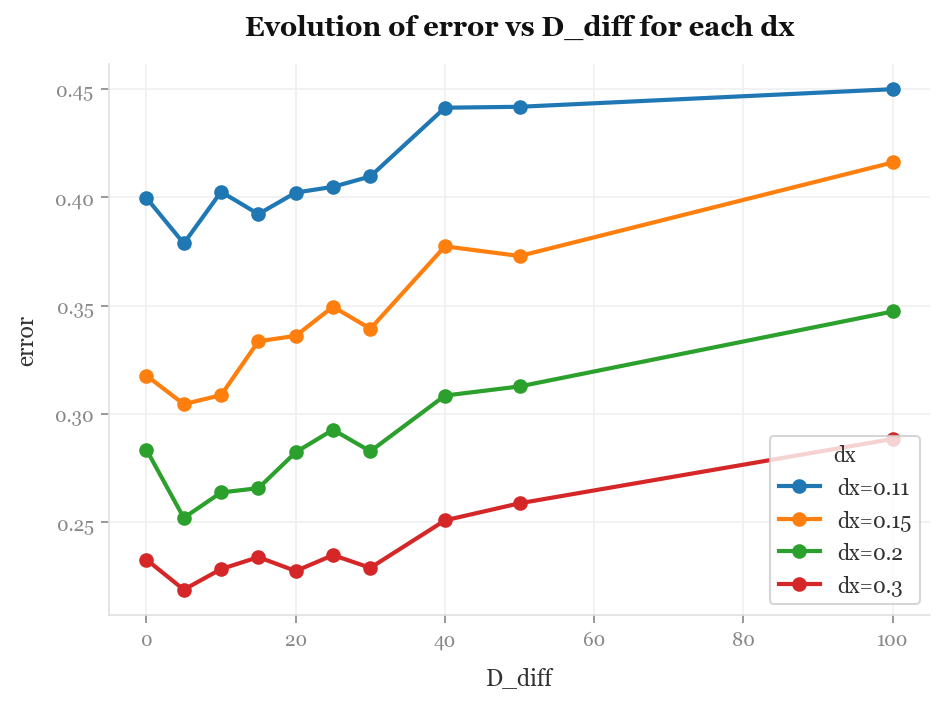

In [24]:
import matplotlib.pyplot as plt

for dx, group in df_mean.groupby('DX'):
    plt.plot(group.index.get_level_values('D_diff'), group['error'], marker='o', label=f'dx={dx}')

plt.xlabel('D_diff')
plt.ylabel('error')
plt.title('Evolution of error vs D_diff for each dx')
plt.legend(title='dx')
plt.grid(True)
plt.tight_layout()
plt.show()

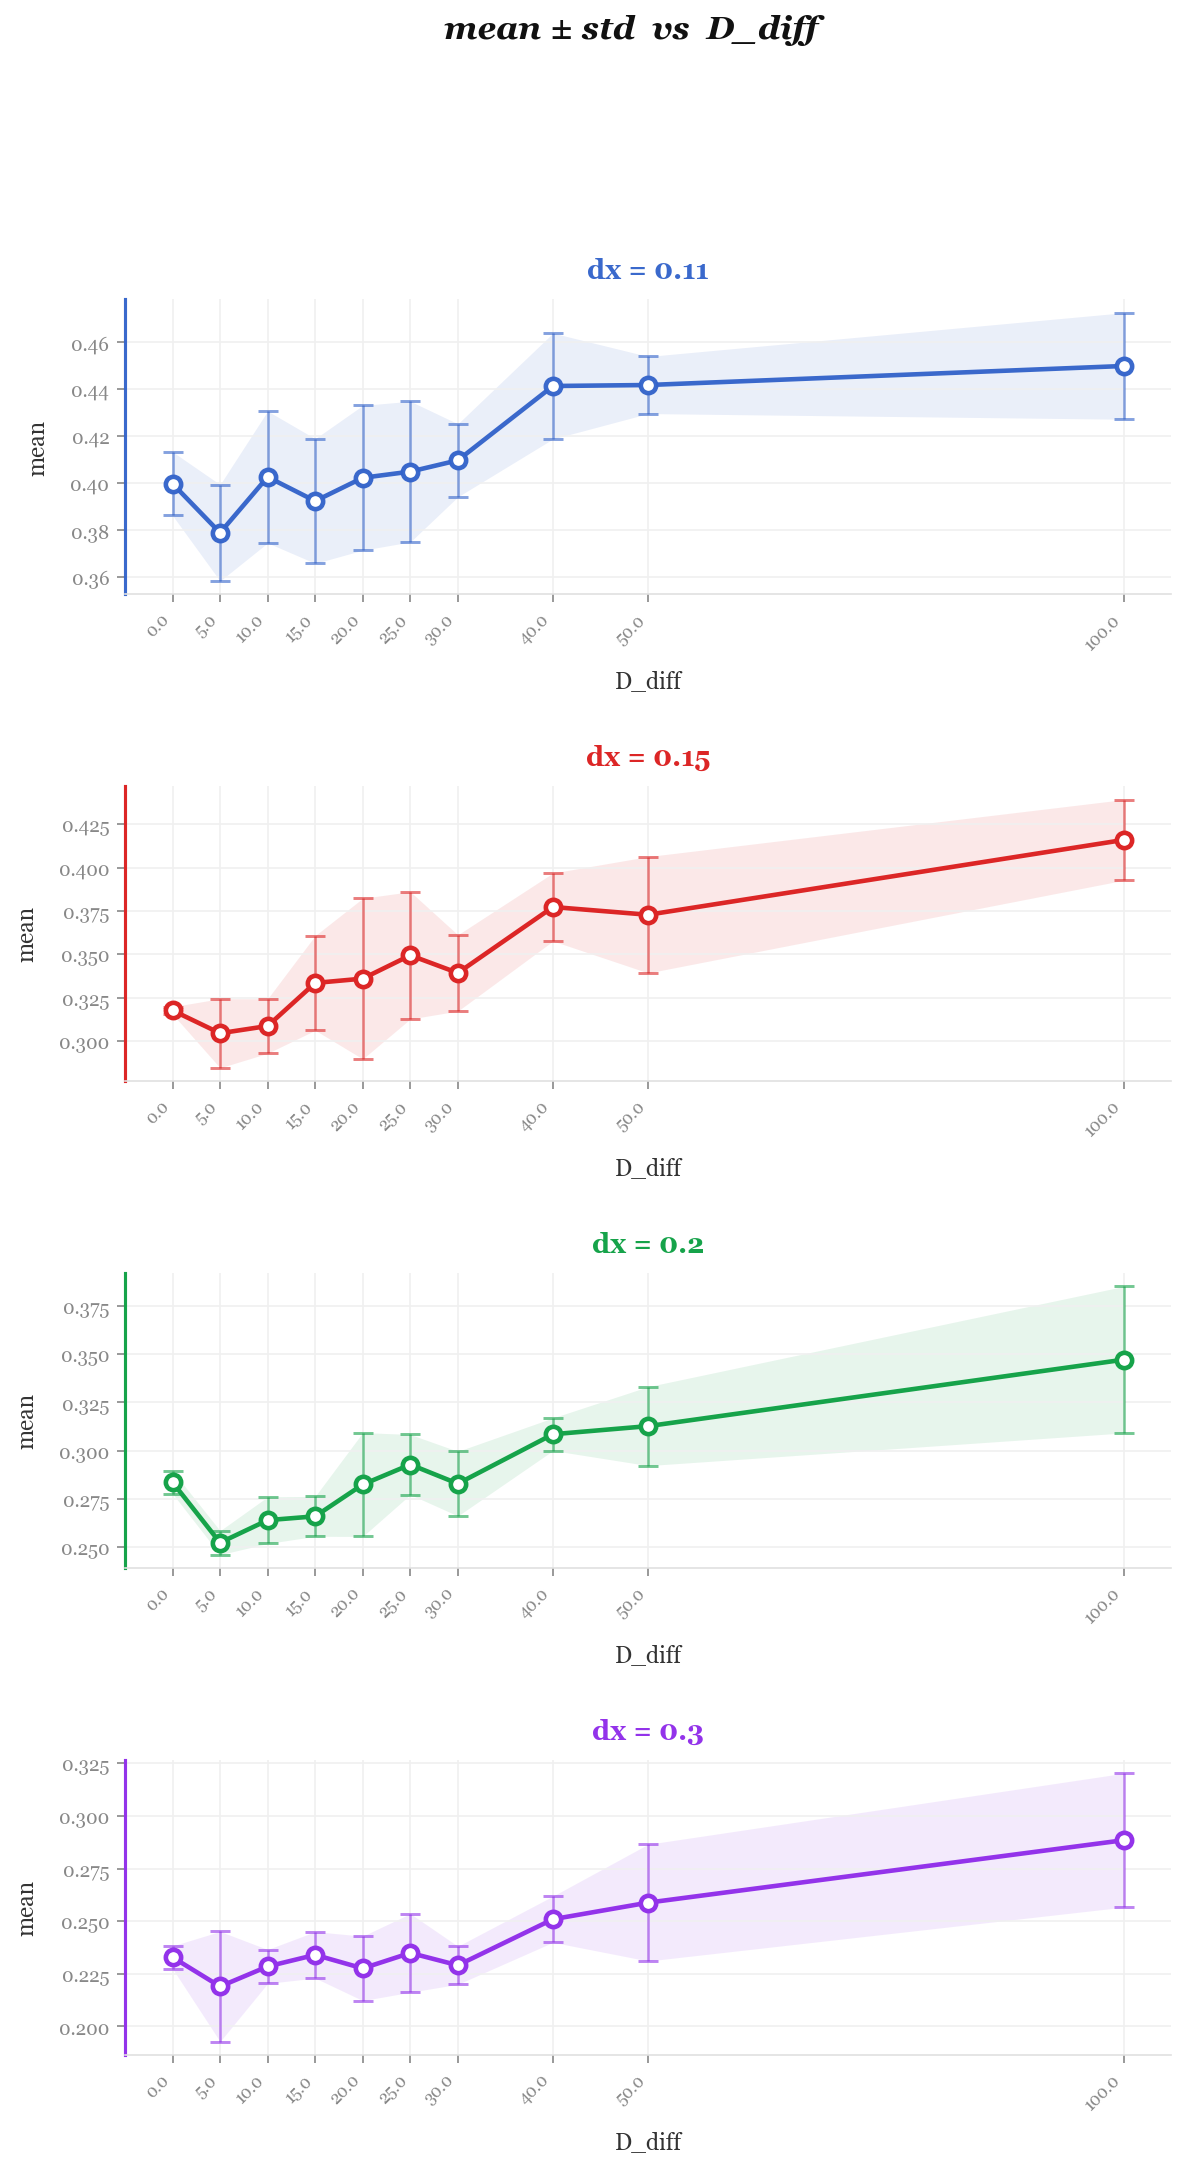

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#e0e0e0",
    "axes.labelcolor":   "#333333",
    "axes.titlesize":    13,
    "axes.titleweight":  "semibold",
    "axes.titlepad":     14,
    "axes.labelsize":    11,
    "axes.labelpad":     8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#f0f0f0",
    "grid.linewidth":    0.8,
    "xtick.color":       "#888888",
    "ytick.color":       "#888888",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "lines.linewidth":   2,
    "font.family":       "serif",
    "font.serif":        ["Georgia", "DejaVu Serif"],
    "text.color":        "#333333",
    "figure.dpi":        150,
})

PALETTE = [
    "#3363caf6",  # blue
    "#dc2626",  # red
    "#16a34a",  # green
    "#9333ea",  # purple
    "#ea580c",  # orange
    "#0891b2",  # teal
]
#───────────────────────────────────────────────────────────────────────────────
# ── Data ──────────────────────────────────────────────────────────────────────
df_stats = df_last.groupby(["D_diff", "DX"])["error"].agg(["mean", "std"]).reset_index()
dx_list  = sorted(df_stats["DX"].unique())
all_ddiff = sorted(df_stats["D_diff"].unique())
n        = len(dx_list)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    n, 1,
    figsize=(9, 3.8 * n),
    gridspec_kw={"hspace": 0.65},
)
if n == 1:
    axes = [axes]

for i, (ax, dx) in enumerate(zip(axes, dx_list)):
    color  = PALETTE[i % len(PALETTE)]
    subset = df_stats[df_stats["DX"] == dx].sort_values("D_diff")

    x, y, err = subset["D_diff"].values, subset["mean"].values, subset["std"].values

    # Shaded ±1 std band
    ax.fill_between(x, y - err, y + err,
                    color=color, alpha=0.10, linewidth=0)

    # Main line
    ax.plot(x, y, color=color, linewidth=2.2, zorder=4)

    # Error-bar caps
    ax.errorbar(x, y, yerr=err,
                fmt="none",
                ecolor=color, elinewidth=1.2,
                capsize=5, capthick=1.4,
                alpha=0.6, zorder=3)

    # Scatter dots
    ax.scatter(x, y,
               s=54, zorder=5,
               facecolors="white", edgecolors=color,
               linewidths=2.2)

    # Title with panel colour
    ax.set_title(f"dx = {dx}", color=color, fontsize=13,
                 fontweight="semibold", pad=10)

    # X-axis — all D_diff values on every panel
    ax.set_xticks(all_ddiff)
    ax.set_xticklabels(
        [str(v) for v in all_ddiff],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_xlabel("D_diff", labelpad=8)
    ax.set_ylabel("mean", labelpad=10)

    ax.tick_params(axis="both", which="both", length=4, width=0.8)

    # Coloured left spine accent
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["left"].set_color(color)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.spines["bottom"].set_color("#e0e0e0")

# ── Super-title ───────────────────────────────────────────────────────────────
fig.suptitle(
    "mean ± std  vs  D_diff",
    fontsize=16, fontweight="bold",
    color="#111111", y=1.005,
    fontstyle="italic",
)

plt.savefig("plot.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()